# personal-cgm-lab - UCB Capstone - Exploratory Data Analysis

This notebook is the bridge between the raw data and the modeling notebooks. Every plot should either confirm a feature is worth including, or surface that I need to handle it before fitting.

**After initial analysis, switched daily features to a 4 AM physiological-day boundary** so overnight fasts don't split across midnight, **plus a fast-vs-feeding window decomposition** so the intermittent fasting effect can be measured cleanly without the calendar-day blur.

**Goals (from the capstone proposal):**

1. Walk ROI (25 vs 45 min): confounded by selection bias - I want to quantify that here.
2. Dinner given lunch: look for sequential meal dependencies.
3. Stable vs spiky meals: per-dish ranking with confidence intervals.
4. Daily mean toward A1C 6.0: daily trend + stationarity check for SARIMAX.

## 1. Setup

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.tsa.stattools import adfuller 
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (10, 5)

DATA_DIR        = os.path.abspath(os.path.join('..', 'data/processed'))
DATA_DIR_RAW    = os.path.abspath(os.path.join('..', 'data/raw'))

per_meal = pd.read_csv(os.path.join(DATA_DIR, 'per_meal_features.csv'), parse_dates=['ts', 'date'])
daily    = pd.read_csv(os.path.join(DATA_DIR, 'daily_features.csv'), parse_dates=['date'])

print(f"per_meal: {per_meal.shape}")
print(f"daily:    {daily.shape}")


per_meal: (393, 39)
daily:    (117, 36)


## 2. Data quality check

Before any analysis: duplicates, missing value coverage, and outlier boundaries. This is on the processed feature matrices (output of `00-build-features.py`), not the raw CSVs.

In [4]:
# â”€â”€ Duplicates â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
print("=== Duplicate check ===")
print(f"per_meal duplicate meal_id rows : {per_meal['meal_id'].duplicated().sum()}")
print(f"per_meal duplicate ts rows      : {per_meal['ts'].duplicated().sum()}")
print(f"daily duplicate date rows       : {daily['date'].duplicated().sum()}")

# â”€â”€ Missing value summary â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
print("\n=== Missing values (per_meal) â€” columns with any nulls ===")
null_pm = per_meal.isnull().sum()
print(null_pm[null_pm > 0].to_string())

print("\n=== Missing values (daily) â€” columns with any nulls ===")
null_d = daily.isnull().sum()
print(null_d[null_d > 0].to_string())

# â”€â”€ Outlier analysis â€” IQR method â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
print("\n=== Outlier analysis (IQR, 1.5x fence) ===")
for label, series in [
    ('peak_delta',    per_meal['peak_delta']),
    ('pre_meal_glucose', per_meal['pre_meal_glucose']),
    ('carbs_g_final', per_meal['carbs_g_final'].dropna()),
    ('cgm glucose_mg_dl', pd.read_csv(
        os.path.join(DATA_DIR_RAW, 'cgm_5min.csv'))['glucose_mg_dl'].dropna()),
]:
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((series < lo) | (series > hi)).sum()
    print(f"  {label:28s}  range [{series.min():.0f}, {series.max():.0f}]"
          f"  fence [{lo:.0f}, {hi:.0f}]  outliers: {n_out} / {len(series)}"
          f"  ({100*n_out/len(series):.1f}%)")

=== Duplicate check ===
per_meal duplicate meal_id rows : 0
per_meal duplicate ts rows      : 1
daily duplicate date rows       : 0

=== Missing values (per_meal) â€” columns with any nulls ===
meal_type                      1
dish_names                    13
food_match                    39
peak_delta                    20
peak_glucose                  20
time_to_peak_min              20
pre_meal_glucose              20
glucose_30min_before_mean     20
glucose_60min_before_mean     20
glucose_velocity_30min        30
carbs_g_final                  4
carbs_grams_logged           262
carbs_grams_estimated        128
carbs_g_lookup                39
protein_g_lookup              42
fat_g_lookup                  47
gl_lookup                    352
minutes_to_first_walk        338

=== Missing values (daily) â€” columns with any nulls ===
mean_glucose_calendar                1
fast_window_mean_glucose            33
feeding_window_mean_glucose          5
fast_window_tir_pct                 

**Data quality notes:**

- No duplicate meal IDs or timestamps are expected. The build script uses the `meal_id` primary key from `meals_v2.csv` and there is no merge step that could fan out rows.
- Missing values in nutrition columns (`carbs_g_final`, `protein_g_lookup`, etc.) are structurally expected â€” not every meal was labeled with a dish name, and not every dish name matched the food lookup table. These are handled by median imputation inside the sklearn pipeline in the modeling notebook, fitted only on training data.
- CGM glucose outliers at the high end are real physiological events, not sensor errors. The Stelo sensor range is 70â€“250 mg/dL; readings near the ceiling are genuine hyperglycemic episodes and should be retained. I am not removing them.

In [5]:
per_meal.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 393 entries, 0 to 392
Data columns (total 39 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   meal_id                       393 non-null    int64         
 1   ts                            393 non-null    datetime64[ns]
 2   date                          393 non-null    datetime64[ns]
 3   dow                           393 non-null    object        
 4   time_bucket                   393 non-null    object        
 5   meal_type                     392 non-null    object        
 6   dish_names                    380 non-null    object        
 7   food_match                    354 non-null    object        
 8   peak_delta                    373 non-null    float64       
 9   peak_glucose                  373 non-null    float64       
 10  time_to_peak_min              373 non-null    float64       
 11  out_of_range_180              39

In [6]:
per_meal.sample(3, random_state=41)

,meal_id,ts,date,dow,time_bucket,meal_type,dish_names,food_match,peak_delta,peak_glucose,...,last_drug,minutes_since_last_glipizide,broke_if_window,broke_window_type,prev_fast_hours,hour,hour_sin,hour_cos,is_weekend,day_index
367,373,2026-05-29 23:40:00,2026-05-29,Friday,night,snack,cappacino and few bites of cake pop,NaN,23.0,189.0,...,Glipizide,370.000000,False,overnight,12.00,23,-0.258819,0.965926,0,117
157,160,2026-03-16 13:27:55,2026-03-16,Monday,afternoon,tea,chai_with_milk_no_sugar,chai_with_milk_no_sugar,98.0,241.0,...,Crestor,207.916667,False,intermittent_skip_breakfast,17.29,13,-0.258819,-0.965926,0,43
25,30,2026-02-09 16:42:27,2026-02-09,Monday,evening,breakfast,idli,idli,144.0,273.0,...,Glipizide,42.450000,False,overnight,12.00,16,-0.866025,-0.500000,0,8


## 2. Daily-level glucose overview

Anchored on the physio-day mean (4 AM). Will keep `mean_glucose_calendar` for endocrinologist-comparable reporting.

In [7]:
print(daily[['mean_glucose', 'mean_glucose_calendar', 'time_in_range_pct', 'gmi_estimate']].describe().round(2))
print(f"\nA1C 6.0 target: GMI ~6.0, mean glucose ~125, TIR > 70%")

       mean_glucose  mean_glucose_calendar  time_in_range_pct  gmi_estimate
count        117.00                 116.00             117.00        117.00
mean         169.52                 169.57              61.55          7.36
std           24.38                  24.04              20.50          0.58
min           95.79                  98.75               0.00          5.60
25%          152.52                 151.22              49.70          6.96
50%          169.66                 168.67              63.50          7.37
75%          184.49                 188.00              78.10          7.72
max          234.76                 236.81             100.00          8.93

A1C 6.0 target: GMI ~6.0, mean glucose ~125, TIR > 70%


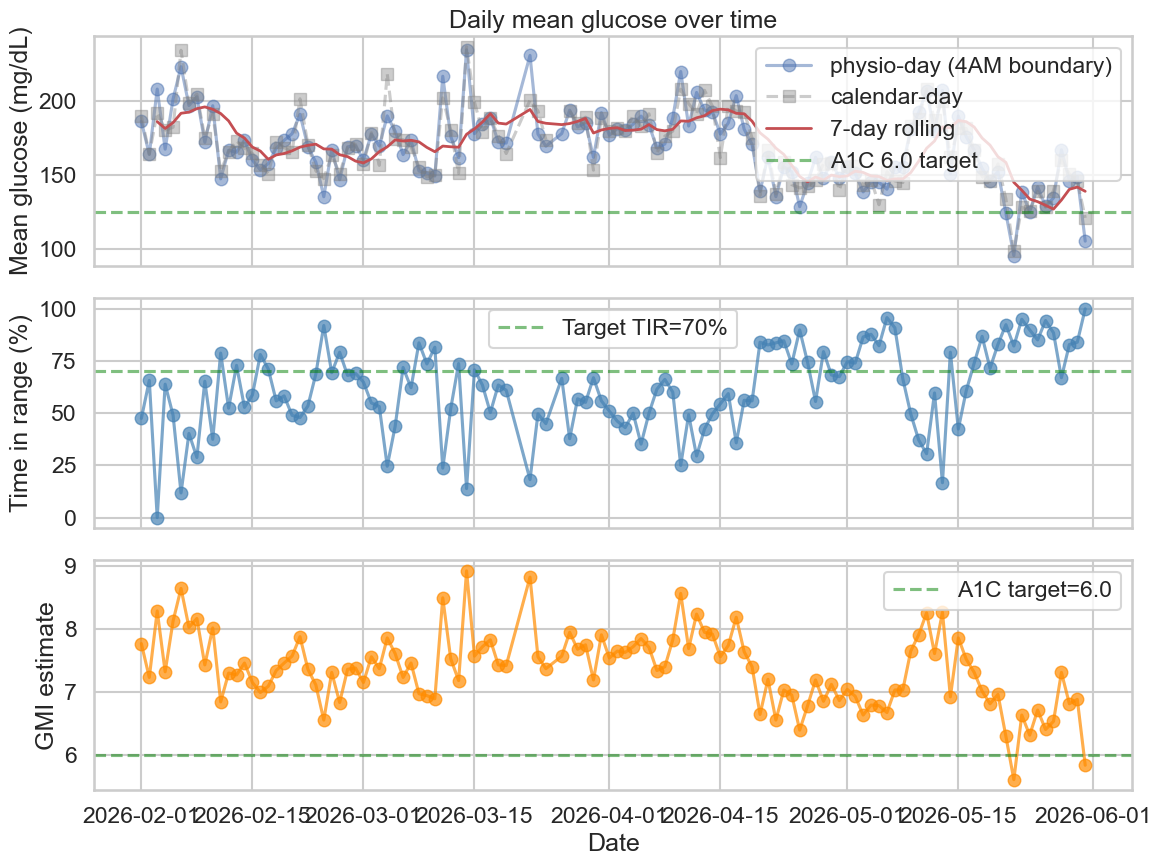

In [8]:
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

axes[0].plot(daily['date'], daily['mean_glucose'], 'o-', alpha=0.5, label='physio-day (4AM boundary)')
axes[0].plot(daily['date'], daily['mean_glucose_calendar'], 's--', alpha=0.4, label='calendar-day', color='gray')
axes[0].plot(daily['date'], daily['mean_glucose_7d_avg_descriptive'], 'r-', linewidth=2, label='7-day rolling')
axes[0].axhline(125, color='green', linestyle='--', alpha=0.5, label='A1C 6.0 target')
axes[0].set_ylabel('Mean glucose (mg/dL)')
axes[0].legend(loc='upper right'); axes[0].set_title('Daily mean glucose over time')

axes[1].plot(daily['date'], daily['time_in_range_pct'], 'o-', alpha=0.7, color='steelblue')
axes[1].axhline(70, color='green', linestyle='--', alpha=0.5, label='Target TIR=70%')
axes[1].set_ylabel('Time in range (%)')
axes[1].legend()

axes[2].plot(daily['date'], daily['gmi_estimate'], 'o-', alpha=0.7, color='darkorange')
axes[2].axhline(6.0, color='green', linestyle='--', alpha=0.5, label='A1C target=6.0')
axes[2].set_ylabel('GMI estimate'); axes[2].set_xlabel('Date')
axes[2].legend()
plt.tight_layout(); plt.show()

**Physio vs calendar.** The two means track within ~1 mg/dL of each other on most days because the 4 AM boundary only re-allocates 4 hours of overnight
readings between dates. The difference is largest on Intermittent Fasting (IF) days where the late-evening fast hours move from one date to the next. On initial analysis, it appeared that IF had no significant impact. 

## 3. Per-meal target distribution

`peak_delta` is my primary regression target. The log1p plot shows whether a log transformation will help the linear model.

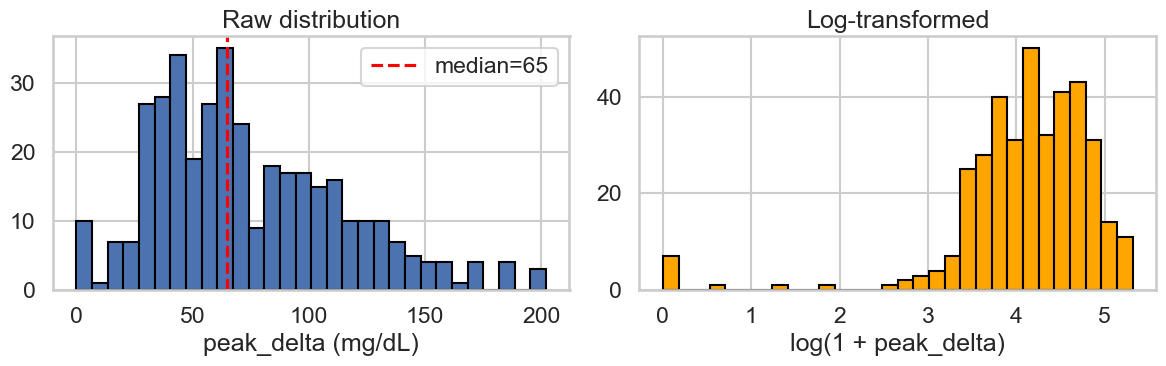

skewness raw: 0.70
skewness log: -2.66


In [9]:
peak_delta = per_meal['peak_delta'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(peak_delta, bins=30, edgecolor='black')
axes[0].set_xlabel('peak_delta (mg/dL)'); axes[0].set_title('Raw distribution')
axes[0].axvline(peak_delta.median(), color='red', linestyle='--',
                label=f'median={peak_delta.median():.0f}')
axes[0].legend()

axes[1].hist(np.log1p(peak_delta), bins=30, edgecolor='black', color='orange')
axes[1].set_xlabel('log(1 + peak_delta)'); axes[1].set_title('Log-transformed')
plt.tight_layout(); plt.show()
print(f"skewness raw: {stats.skew(peak_delta):.2f}")
print(f"skewness log: {stats.skew(np.log1p(peak_delta)):.2f}")

## 3b. Baseline contamination check: is `pre_meal_glucose` signal real?

`peak_delta` is defined as `peak_glucose âˆ’ pre_meal_glucose`, so `pre_meal_glucose` appears on both sides of any regression: once subtracted in the target, and again as a predictor. This creates a **mechanical negative correlation** that is present by construction, regardless of physiology.

The decomposition is exact:

```
slope(peak_delta ~ pre_meal_glucose) = slope(peak_glucose ~ pre_meal_glucose) âˆ’ 1
                                        â””â”€â”€ real biology â”€â”€â”˜                   â””â”€â”€ pure math â”€â”€â”˜
```

The `âˆ’1` term is always there. The right panel below tests whether `pre_meal_glucose` genuinely predicts the *absolute* peak level â€” if that slope is near zero and non-significant, the negative coefficient in the regression model is almost entirely an artefact of the target definition.

=== peak_delta  ~ pre_meal_glucose ===
  slope = -0.354  (SE=0.051, p=0.0000,  r2=0.116)

=== peak_glucose ~ pre_meal_glucose ===
  slope = 0.645  (SE=0.051, p=0.0000,  r2=0.302)

=== Decomposition: slope(peak_delta) = slope(peak_glucose) - 1 ===
  Math adds:     -1.000  (construction â€” always present)
  Biology adds:  +0.645  (real signal, p=0.0000)
  Net observed:  -0.355  (what the model sees)
  Check: -0.354 =? 0.645 - 1 = -0.355  ->  FAIL

  H0 (no biology): slope(peak_glucose ~ pre_meal_glucose) = 0
  p = 0.0000  -> real signal present


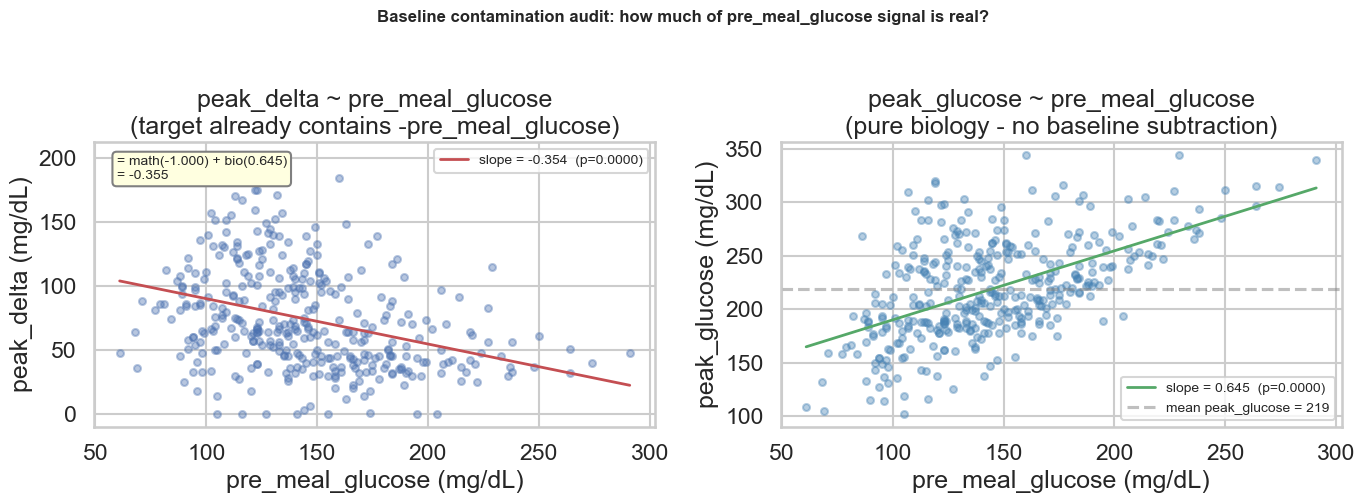

In [10]:
valid = per_meal[['pre_meal_glucose', 'peak_delta', 'peak_glucose']].dropna()

slope_d, intercept_d, r_d, p_d, se_d = stats.linregress(valid['pre_meal_glucose'], valid['peak_delta'])
slope_g, intercept_g, r_g, p_g, se_g = stats.linregress(valid['pre_meal_glucose'], valid['peak_glucose'])

print("=== peak_delta  ~ pre_meal_glucose ===")
print(f"  slope = {slope_d:.3f}  (SE={se_d:.3f}, p={p_d:.4f},  r2={r_d**2:.3f})")
print("\n=== peak_glucose ~ pre_meal_glucose ===")
print(f"  slope = {slope_g:.3f}  (SE={se_g:.3f}, p={p_g:.4f},  r2={r_g**2:.3f})")
print("\n=== Decomposition: slope(peak_delta) = slope(peak_glucose) - 1 ===")
print(f"  Math adds:     -1.000  (construction â€” always present)")
print(f"  Biology adds:  {slope_g:+.3f}  (real signal, p={p_g:.4f})")
print(f"  Net observed:  {slope_g - 1:.3f}  (what the model sees)")
print(f"  Check: {slope_d:.3f} =? {slope_g:.3f} - 1 = {slope_g - 1:.3f}  ->  "
      f"{'PASS' if abs(slope_d - (slope_g - 1)) < 1e-6 else 'FAIL'}")
print(f"\n  H0 (no biology): slope(peak_glucose ~ pre_meal_glucose) = 0")
print(f"  p = {p_g:.4f}  -> {'real signal present' if p_g < 0.05 else 'no significant biology detected'}")

# â”€â”€ Visualization â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
xs = np.linspace(valid['pre_meal_glucose'].min(), valid['pre_meal_glucose'].max(), 100)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(valid['pre_meal_glucose'], valid['peak_delta'], alpha=0.4, s=25)
axes[0].plot(xs, slope_d * xs + intercept_d, 'r-', linewidth=2,
             label=f'slope = {slope_d:.3f}  (p={p_d:.4f})')
axes[0].set_xlabel('pre_meal_glucose (mg/dL)')
axes[0].set_ylabel('peak_delta (mg/dL)')
axes[0].set_title('peak_delta ~ pre_meal_glucose\n(target already contains -pre_meal_glucose)')
axes[0].legend(fontsize=10)
axes[0].annotate(
    f'= math(-1.000) + bio({slope_g:.3f})\n= {slope_g - 1:.3f}',
    xy=(0.04, 0.87), xycoords='axes fraction', fontsize=10,
    bbox=dict(boxstyle='round,pad=0.3', fc='lightyellow', ec='gray'))

axes[1].scatter(valid['pre_meal_glucose'], valid['peak_glucose'], alpha=0.4, s=25, color='steelblue')
axes[1].plot(xs, slope_g * xs + intercept_g, 'g-', linewidth=2,
             label=f'slope = {slope_g:.3f}  (p={p_g:.4f})')
axes[1].axhline(valid['peak_glucose'].mean(), color='gray', linestyle='--', alpha=0.5,
                label=f'mean peak_glucose = {valid["peak_glucose"].mean():.0f}')
axes[1].set_xlabel('pre_meal_glucose (mg/dL)')
axes[1].set_ylabel('peak_glucose (mg/dL)')
axes[1].set_title('peak_glucose ~ pre_meal_glucose\n(pure biology - no baseline subtraction)')
axes[1].legend(fontsize=10)

plt.suptitle('Baseline contamination audit: how much of pre_meal_glucose signal is real?',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 4. Carbs (input signal) to peak_delta (outcome)

The textbook relationship: more carbs -> bigger spike. (NOTE: carbs are captured from product nutrition label when available, estimated when missing or averaged if portion size was 1.5 etc)

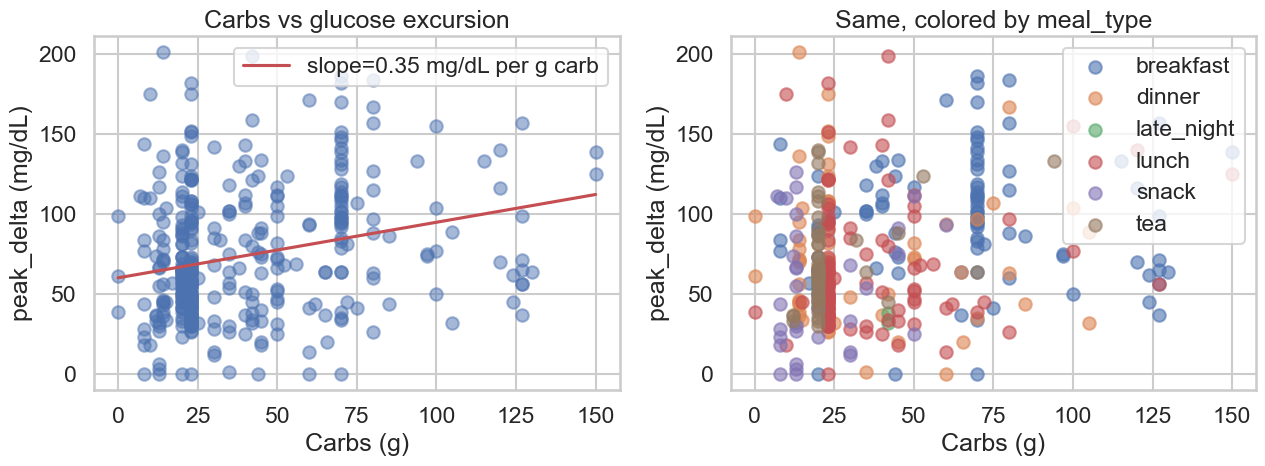

Pearson r = 0.252, p = 8.96e-07, n = 369


In [11]:
sub = per_meal.dropna(subset=['carbs_g_final', 'peak_delta'])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(sub['carbs_g_final'], sub['peak_delta'], alpha=0.5)
m, b = np.polyfit(sub['carbs_g_final'], sub['peak_delta'], 1)
xs = np.linspace(sub['carbs_g_final'].min(), sub['carbs_g_final'].max(), 50)
axes[0].plot(xs, m*xs + b, 'r-', label=f'slope={m:.2f} mg/dL per g carb')
axes[0].set_xlabel('Carbs (g)'); axes[0].set_ylabel('peak_delta (mg/dL)')
axes[0].set_title('Carbs vs glucose excursion')
axes[0].legend()

for mt, grp in sub.groupby('meal_type'):
    axes[1].scatter(grp['carbs_g_final'], grp['peak_delta'], label=mt, alpha=0.6)
axes[1].set_xlabel('Carbs (g)'); axes[1].set_ylabel('peak_delta (mg/dL)')
axes[1].set_title('Same, colored by meal_type')
axes[1].legend()
plt.tight_layout(); plt.show()

r, p = stats.pearsonr(sub['carbs_g_final'], sub['peak_delta'])
print(f"Pearson r = {r:.3f}, p = {p:.2e}, n = {len(sub)}")

## 5. Walk effect

The naive comparison is misleading because of selection bias: walks happen *after* meals you anticipate will spike. It maybe a type of `data signal leak` that should be tested by removing from feature. 

In [12]:
per_meal['walked_after'] = (per_meal['walk_min_within_90'] > 0).astype(int)
sub = per_meal.dropna(subset=['peak_delta'])
naive = sub.groupby('walked_after').agg(
    n=('peak_delta', 'count'),
    mean_peak_delta=('peak_delta', 'mean'),
).round(1)
print('=== NAIVE comparison (misleading) ===')
print(naive)

=== NAIVE comparison (misleading) ===
                n  mean_peak_delta
walked_after                      
0             339             73.7
1              34             80.0


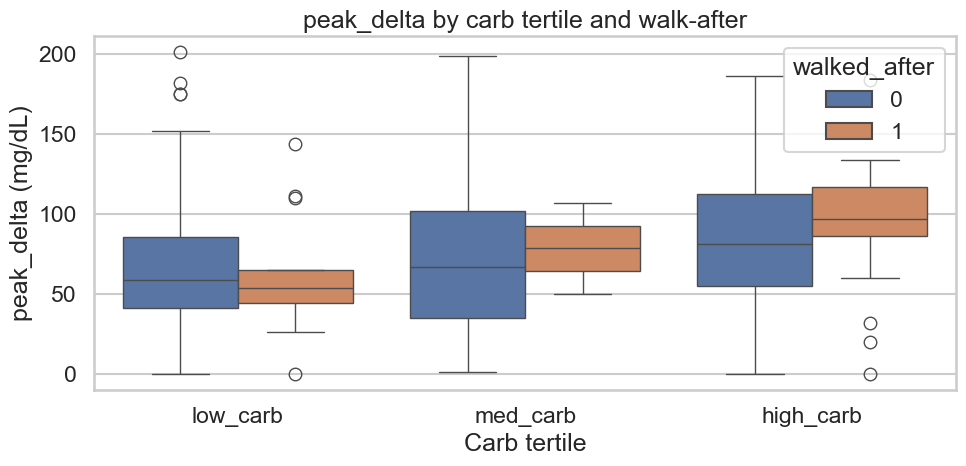

In [13]:
sub2 = sub.dropna(subset=['carbs_g_final']).copy()
sub2['carb_tertile'] = pd.qcut(sub2['carbs_g_final'], 3,
                               labels=['low_carb', 'med_carb', 'high_carb'])

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=sub2, x='carb_tertile', y='peak_delta',
            hue='walked_after', ax=ax)
ax.set_title('peak_delta by carb tertile and walk-after')
ax.set_xlabel('Carb tertile'); ax.set_ylabel('peak_delta (mg/dL)')
plt.tight_layout(); plt.show()

**Watch the n's.** With only ~22 meals followed by a walk, splitting 3 ways
leaves single-digit cells. Goal 1 will need either more walk data going
forward or a regression that uses every meal's row (not just walked ones)
and treats walk minutes as a continuous regressor.

## 6. Per-dish ranking - which meals stabilize vs spike?

Goal 3. Bootstrap 95% CI on mean peak_delta per dish (n >= 3).

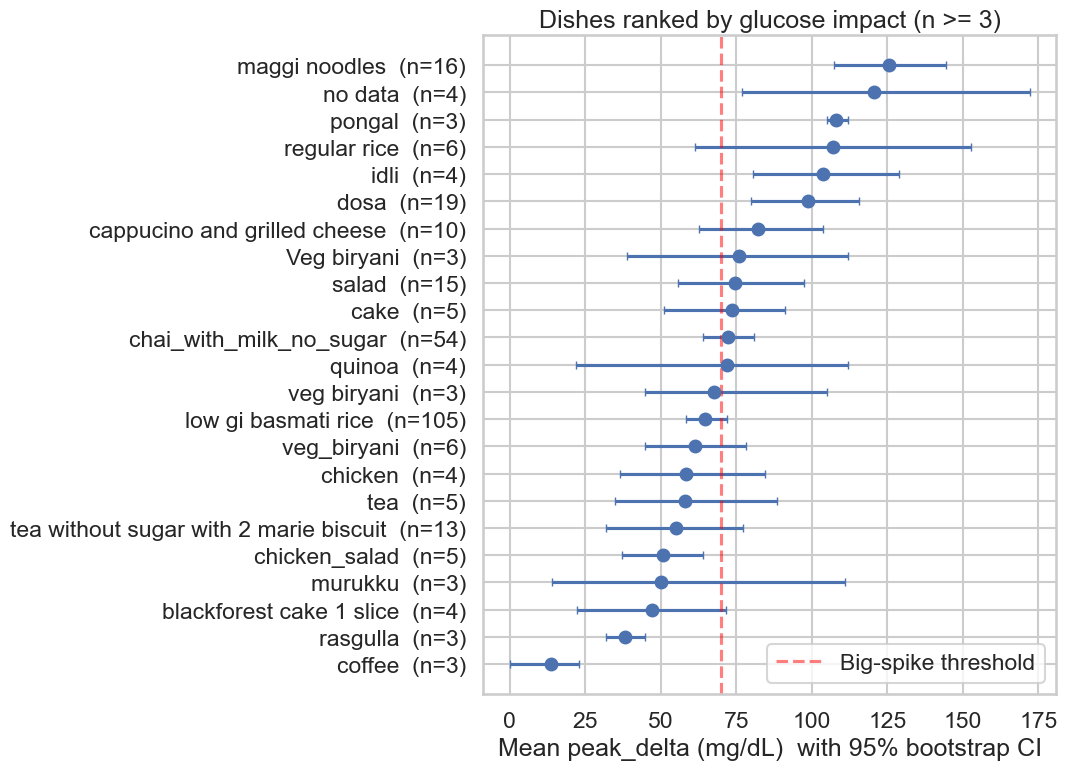

,dish_names,n,mean_peak,median_peak,ci_lo,ci_hi
33,coffee,3,13.666667,18.0,0.000000,23.000000
63,rasgulla,3,38.333333,38.0,32.000000,45.000000
12,blackforest cake 1 slice,4,47.000000,50.5,22.500000,71.500000
51,murukku,3,50.000000,25.0,14.000000,111.000000
28,chicken_salad,5,50.800000,51.0,37.170000,64.200000
69,tea without sugar with 2 marie biscuit,13,55.000000,55.0,31.844231,77.157692
67,tea,5,58.200000,37.0,35.000000,88.600000
23,chicken,4,58.250000,51.0,36.500000,84.500000
75,veg_biryani,6,61.333333,59.0,45.000000,78.166667
48,low gi basmati rice,105,64.828571,55.0,58.332619,72.076667


In [14]:
def bootstrap_ci(values, n_boot=2000, alpha=0.05):
    rng = np.random.default_rng(42)
    boots = [np.mean(rng.choice(values, size=len(values), replace=True)) for _ in range(n_boot)]
    return np.percentile(boots, [100*alpha/2, 100*(1-alpha/2)])

dish = per_meal.dropna(subset=['peak_delta','dish_names']) \
               .groupby('dish_names') \
               .agg(n=('peak_delta','count'), mean_peak=('peak_delta','mean'), median_peak=('peak_delta','median'), peak_values=('peak_delta', list)).reset_index()

dish[['ci_lo','ci_hi']] = dish['peak_values'].apply(
    lambda v: pd.Series(bootstrap_ci(v)) if len(v) >= 2 else pd.Series([np.nan, np.nan])
)
dish = dish[dish['n'] >= 3].sort_values('mean_peak')

fig, ax = plt.subplots(figsize=(11, max(5, 0.35*len(dish))))
ax.errorbar(dish['mean_peak'], range(len(dish)),
            xerr=[dish['mean_peak'] - dish['ci_lo'],
                  dish['ci_hi'] - dish['mean_peak']],
            fmt='o', capsize=3)
ax.set_yticks(range(len(dish)))
ax.set_yticklabels([f"{d}  (n={n})" for d, n in zip(dish['dish_names'], dish['n'])])
ax.set_xlabel('Mean peak_delta (mg/dL)  with 95% bootstrap CI')
ax.set_title('Dishes ranked by glucose impact (n >= 3)')
ax.axvline(70, color='red', linestyle='--', alpha=0.5, label='Big-spike threshold')
ax.legend()
plt.tight_layout(); plt.show()
display(dish[['dish_names','n','mean_peak','median_peak','ci_lo','ci_hi']])

## 7. Time-of-day & day-of-week patterns

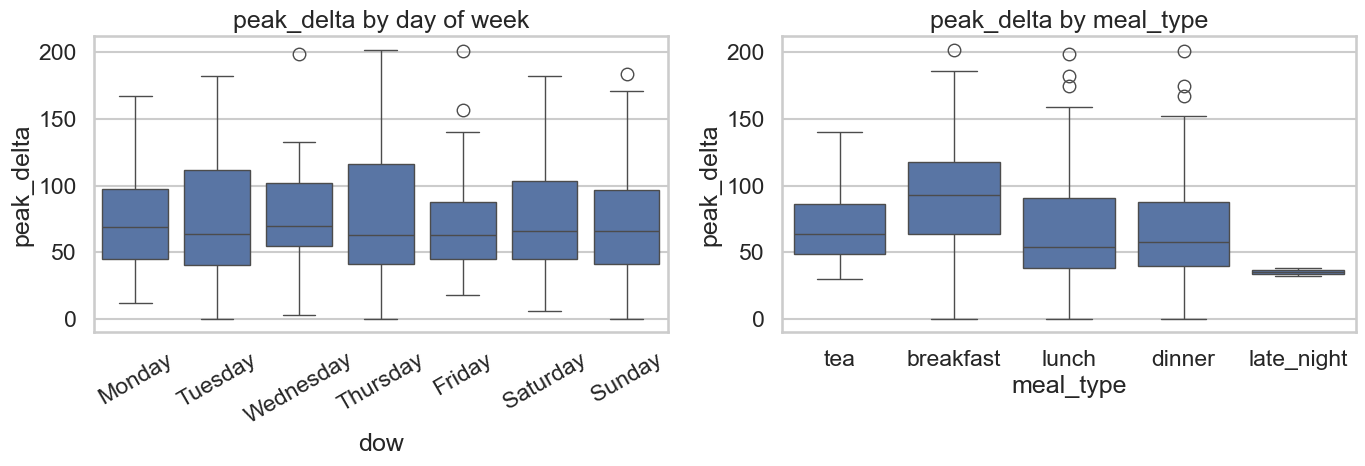

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=per_meal, x='dow', y='peak_delta', order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'], ax=axes[0])
axes[0].set_title('peak_delta by day of week')
axes[0].tick_params(axis='x', rotation=30)

sns.boxplot(data=per_meal, x='meal_type', y='peak_delta', order=['tea','breakfast','lunch','dinner','late_night'], ax=axes[1])
axes[1].set_title('peak_delta by meal_type')
plt.tight_layout(); plt.show()

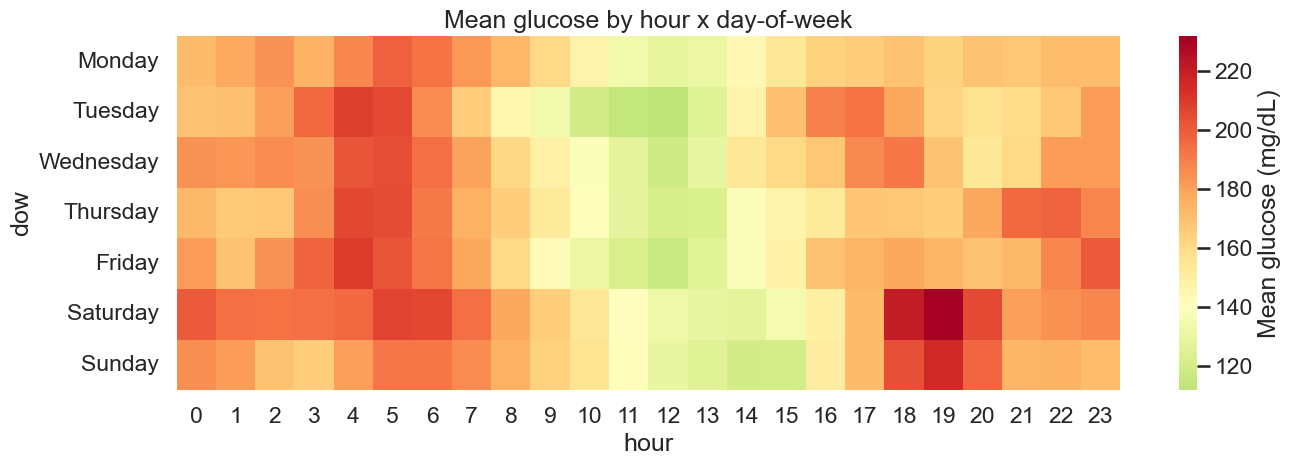

In [16]:
cgm = pd.read_csv(os.path.join(DATA_DIR, '..', 'raw', 'cgm_5min.csv'), parse_dates=['ts'])
cgm['hour'] = cgm['ts'].dt.hour
cgm['dow'] = cgm['ts'].dt.day_name()
heat = cgm.groupby(['dow','hour'])['glucose_mg_dl'].mean().unstack()
heat = heat.reindex(['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(heat, cmap='RdYlGn_r', center=140, ax=ax, cbar_kws={'label': 'Mean glucose (mg/dL)'})
ax.set_title('Mean glucose by hour x day-of-week')
plt.tight_layout(); 
plt.show()

## 8. Fasting-window vs feeding-window decomposition

Shifted the question away from "does intermittent fasting help?" on a per-day basis. Instead of comparing calendar IF days vs non-IF days (which is muddled by partial-day fasts straddling midnight), I compare glucose during *actual* fasting hours vs *actual* eating hours, regardless of date.

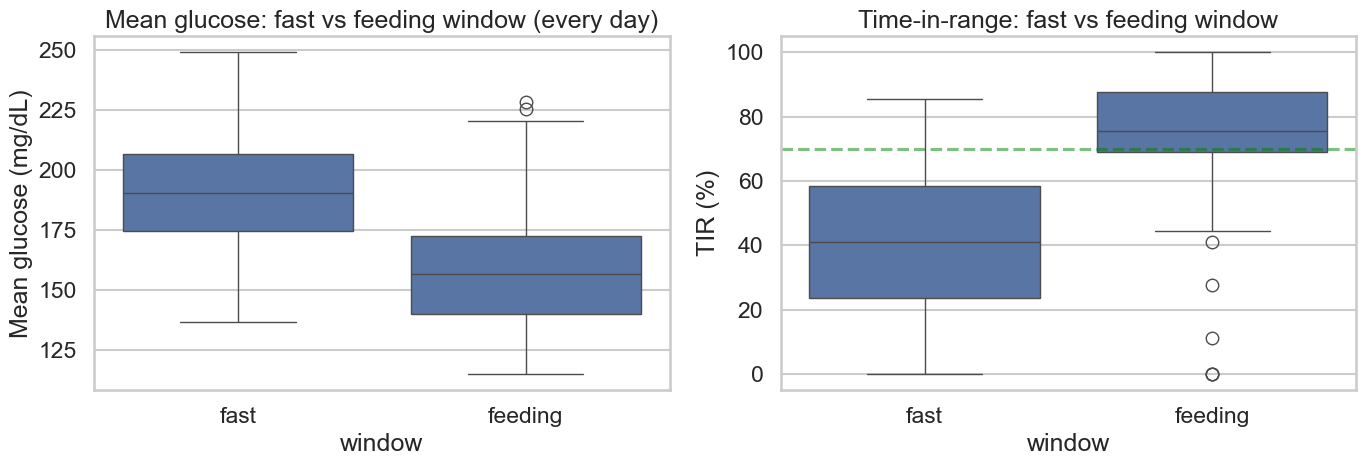

Paired t-test (fasting vs feeding mean glucose, n=79):
  fasting mean    = 192.2
  feeding mean = 157.7
  diff         = -34.4 mg/dL (feeding higher)
  t=11.23, p=5.91e-18


In [17]:
# All days: fast vs feeding window mean
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Daily-mean comparison
days_clean = daily.dropna(subset=['fast_window_mean_glucose',
                                   'feeding_window_mean_glucose'])
melt_means = pd.melt(days_clean,
                     id_vars=['date'],
                     value_vars=['fast_window_mean_glucose',
                                 'feeding_window_mean_glucose'],
                     var_name='window', value_name='glucose')
melt_means['window'] = melt_means['window'].str.replace(
    '_mean_glucose', '').str.replace('_window', '')
sns.boxplot(data=melt_means, x='window', y='glucose', ax=axes[0])
axes[0].set_title('Mean glucose: fast vs feeding window (every day)')
axes[0].set_ylabel('Mean glucose (mg/dL)')

# TIR comparison
melt_tir = pd.melt(days_clean, id_vars=['date'], value_vars=['fast_window_tir_pct', 'feeding_window_tir_pct'], var_name='window', value_name='tir_pct')
melt_tir['window'] = melt_tir['window'].str.replace('_tir_pct', '').str.replace('_window', '')
sns.boxplot(data=melt_tir, x='window', y='tir_pct', ax=axes[1])
axes[1].set_title('Time-in-range: fast vs feeding window')
axes[1].set_ylabel('TIR (%)')
axes[1].axhline(70, color='green', linestyle='--', alpha=0.5)
plt.tight_layout(); plt.show()

# Paired t-test
fast_means = days_clean['fast_window_mean_glucose']
feed_means = days_clean['feeding_window_mean_glucose']
t, p = stats.ttest_rel(fast_means, feed_means)
print(f"Paired t-test (fasting vs feeding mean glucose, n={len(days_clean)}):")
print(f"  fasting mean    = {fast_means.mean():.1f}")
print(f"  feeding mean = {feed_means.mean():.1f}")
print(f"  diff         = {feed_means.mean() - fast_means.mean():+.1f} mg/dL " f"(feeding higher)")
print(f"  t={t:.2f}, p={p:.2e}")

## 8b. IF days vs non-IF days : fasting window only

Now compare the *fast-window mean* on IF days vs non-IF days. This isolates "longer fasts give a deeper drop" from "calendar IF day mean" muddle.

C:\Users\anant\AppData\Local\Temp\ipykernel_9132\349246328.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['non-IF', 'IF'])
C:\Users\anant\AppData\Local\Temp\ipykernel_9132\349246328.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['non-IF', 'IF'])


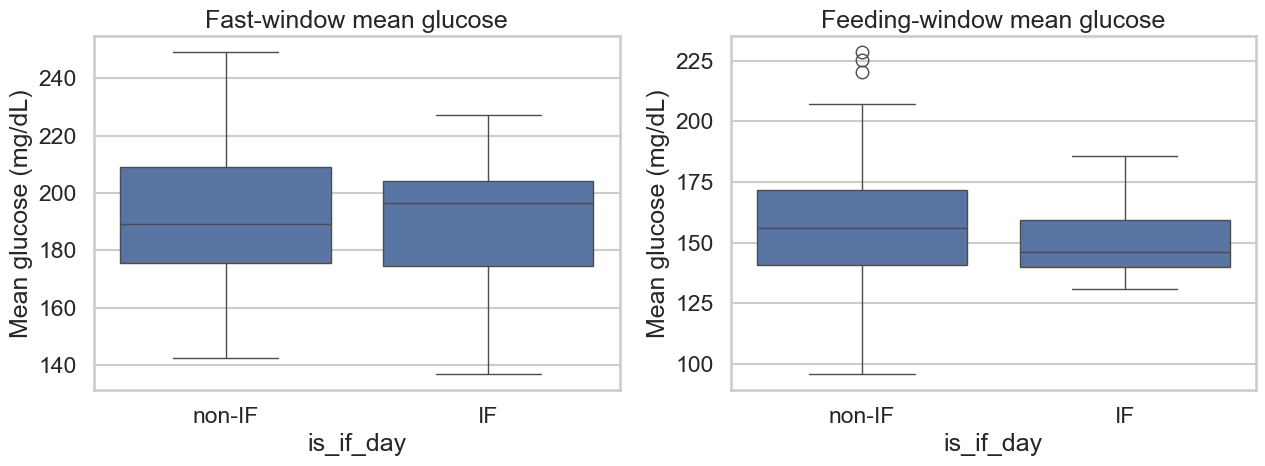

  diff = -2.4 mg/dL,  t=0.35, p=0.730


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(data=daily, x='is_if_day', y='fast_window_mean_glucose', ax=axes[0])
axes[0].set_xticklabels(['non-IF', 'IF'])
axes[0].set_title('Fast-window mean glucose')
axes[0].set_ylabel('Mean glucose (mg/dL)')

sns.boxplot(data=daily, x='is_if_day', y='feeding_window_mean_glucose', ax=axes[1])
axes[1].set_xticklabels(['non-IF', 'IF'])
axes[1].set_title('Feeding-window mean glucose')
axes[1].set_ylabel('Mean glucose (mg/dL)')
plt.tight_layout(); plt.show()

# Stats
g0 = daily.loc[daily['is_if_day']==0, 'fast_window_mean_glucose'].dropna()
g1 = daily.loc[daily['is_if_day']==1, 'fast_window_mean_glucose'].dropna()
t, p = stats.ttest_ind(g0, g1, equal_var=False)

print(f"  diff = {g1.mean() - g0.mean():+.1f} mg/dL,  t={t:.2f}, p={p:.3f}")

**Reading these plots:**

- The first panel (fast vs feeding, all days) is the headline result: my glucose is materially lower during fasted hours regardless of IF status. This is the clearest evidence that fasting itself is doing real work, not just the IF labeling.
- The second pair (IF vs non-IF, holding window type constant) tests whether longer fasts deliver a deeper drop than overnight ones. With only ~14 IF days in the dataset, the confidence intervals are wide and I wouldn't read much into the comparison yet.

## 9. SARIMAX prep - stationarity, ACF, PACF

For the daily mean glucose forecasting model (goal 4). I'm using the **physio-day** mean as the target since it cleanly attributes overnight readings to the right date rather than splitting them across midnight.

In [19]:
y = daily['mean_glucose'].dropna()
adf = adfuller(y, autolag='AIC')
print(f"ADF test on daily mean glucose (physio-day):")
print(f"  statistic = {adf[0]:.3f}, p-value = {adf[1]:.4f}")
print(f"  conclusion: {'STATIONARY' if adf[1] < 0.05 else 'NON-STATIONARY (need differencing)'}")
adf1 = adfuller(y.diff().dropna(), autolag='AIC')
print(f"\nADF on first-differenced series:")
print(f"  p-value = {adf1[1]:.4f}  -> "
      f"{'stationary after d=1' if adf1[1] < 0.05 else 'still non-stationary'}")

ADF test on daily mean glucose (physio-day):
  statistic = -2.572, p-value = 0.0990
  conclusion: NON-STATIONARY (need differencing)

ADF on first-differenced series:
  p-value = 0.0000  -> stationary after d=1


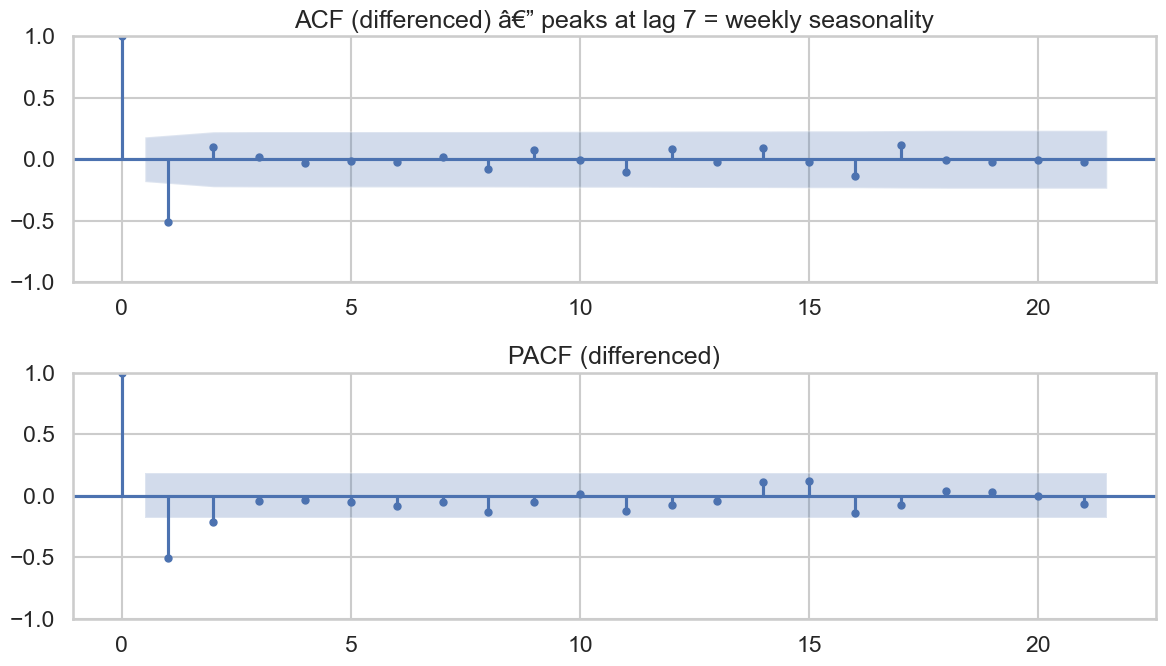

In [20]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7))
plot_acf(y.diff().dropna(), lags=21, ax=axes[0])
axes[0].set_title('ACF (differenced) â€” peaks at lag 7 = weekly seasonality')
plot_pacf(y.diff().dropna(), lags=21, ax=axes[1], method='ywm')
axes[1].set_title('PACF (differenced)')
plt.tight_layout(); plt.show()

**Reading these for SARIMAX(p,d,q)(P,D,Q,s):**

- The ADF p-value tells me whether `d=0` (already stationary) or `d=1` (needs one difference).
- PACF cuts off at lag â†’ AR order `p`. ACF cuts off at lag â†’ MA order `q`.
- Spikes at lag 7 suggest weekly seasonality, so `s=7` with `(P,D,Q)=(1,0,1)` is a reasonable starting point.

Starting model to fit: **SARIMAX(1,1,1)(1,0,1,7)** with exogenous regressors `[total_walk_min, total_carbs, is_if_day, doses_taken]`.

## 10. Daily-feature correlation matrix

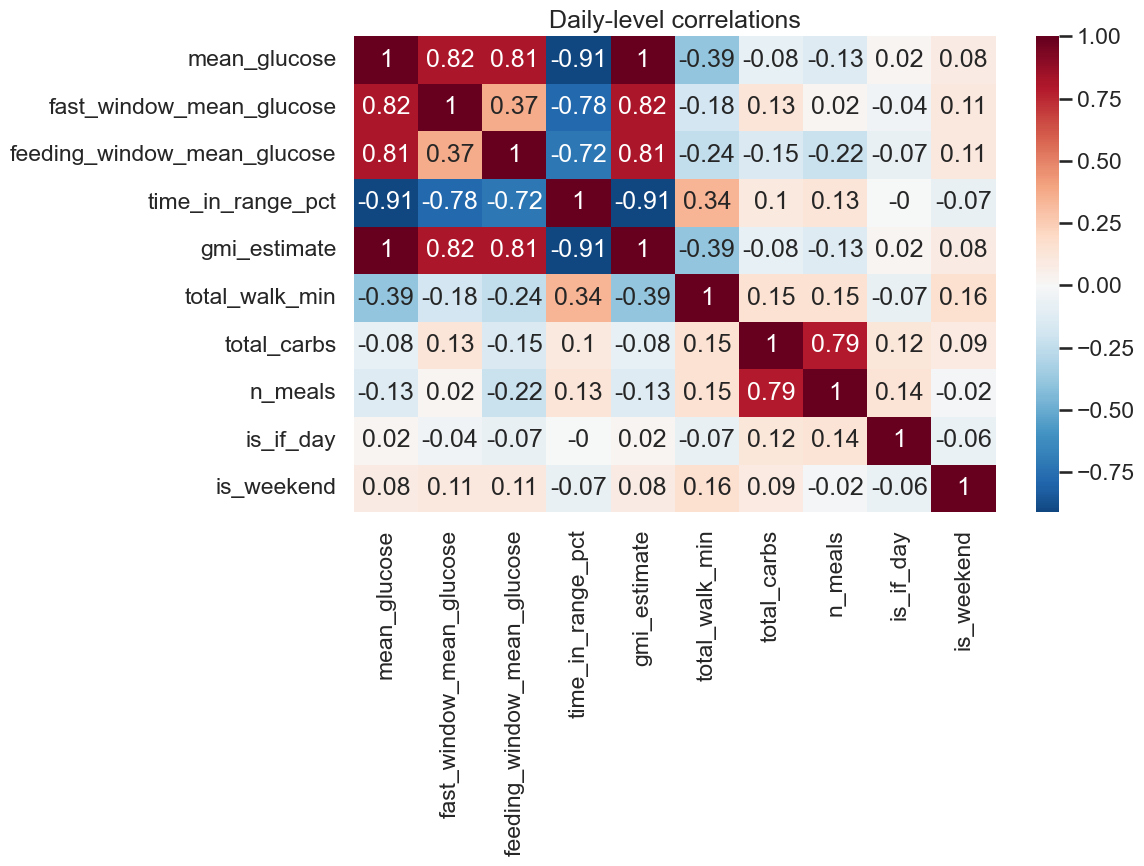

In [21]:
cols = ['mean_glucose', 'fast_window_mean_glucose',
        'feeding_window_mean_glucose', 'time_in_range_pct', 'gmi_estimate',
        'total_walk_min', 'total_carbs', 'n_meals', 'is_if_day', 'is_weekend']
corr = daily[cols].corr().round(2)

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr, annot=True, cmap='RdBu_r', center=0, ax=ax)
ax.set_title('Daily-level correlations')
plt.tight_layout(); plt.show()

## Next steps

1. **Per-meal regression** - start with linear regression.  Hold out the last ~3 weeks as a test set.
2. **Gradient-boosted model** for the same target; compare RMSE; SHAP for importance.
3. **Daily SARIMAX** with seasonality settings inferred above. Try both  `mean_glucose` and `feeding_window_mean_glucose` as targets.
4. **Recommendation layer** - given a predicted high, enumerate intervention candidates (walk 25/45 min, food swap to a low-CI dish) and pick the one with the lowest  predicted peak.

## 11. Hourly CGM features - basis for the SARIMAX time-series model

The daily SARIMAX (`02-sarimax-model.ipynb`) collapsed 22,178 readings into 84 daily means. That destroyed the behavioral signal: a 30-minute walk occupies ~0.02 of a day, indistinguishable from noise at daily resolution. `hourly_features.csv` (built by `scripts/01-build-hourly.py`) keeps the time axis at one-hour steps (~2,076 rows).

Four visualizations motivate the design choices in that feature matrix:
1. The full hourly series - scale of the signal and sensor gaps
2. The intraday diurnal profile - the seasonal pattern SARIMAX(s=24) must model
3. Behavior features by hour of day - exposes the glipizide confounding problem
4. Carb-decay illustration - shows how `carb_load_decayed` (tau=75 min)    tracks the post-meal glucose response

In [22]:
hourly = pd.read_csv(
    os.path.join(DATA_DIR, "hourly_features.csv"), parse_dates=["ts"]
).sort_values("ts").reset_index(drop=True)

print(f"Rows: {len(hourly)}  |  "
      f"non-null glucose: {hourly['glucose_hourly_mean'].notna().sum()}  |  "
      f"sensor gaps (NaN after interpolation): {hourly['glucose_hourly_mean'].isna().sum()}")
print(f"Date range: {hourly['ts'].min().date()} -> {hourly['ts'].max().date()}")
print(f"Mean glucose: {hourly['glucose_hourly_mean'].mean():.1f} mg/dL")

Rows: 2851  |  non-null glucose: 2615  |  sensor gaps (NaN after interpolation): 236
Date range: 2026-02-01 -> 2026-05-31
Mean glucose: 168.9 mg/dL


### 11a. Full hourly series and sensor gaps

Gray bands mark hours where `glucose_n_readings == 0` and no interpolation was
possible (gaps > 2 consecutive hours). The longest is 63 h - a sensor
replacement. Statsmodels' Kalman filter handles these as missing `endog` natively.

In [23]:
g = hourly.set_index("ts")["glucose_hourly_mean"]
roll24 = g.rolling(24, min_periods=12).mean()

fig, ax = plt.subplots(figsize=(14, 4))

# Shade long sensor gaps (n_readings=0, NaN glucose)
gap_mask = hourly["glucose_n_readings"] == 0
in_gap   = False
gap_start = None
for i, (ts_val, is_gap) in enumerate(zip(hourly["ts"], gap_mask)):
    if is_gap and not in_gap:
        gap_start = ts_val
        in_gap    = True
    elif not is_gap and in_gap:
        ax.axvspan(gap_start, ts_val, color="lightcoral", alpha=0.25, lw=0)
        in_gap = False
if in_gap:
    ax.axvspan(gap_start, hourly["ts"].iloc[-1], color="lightcoral", alpha=0.25, lw=0)

ax.plot(g.index, g.values, linewidth=0.6, color="steelblue", alpha=0.55,
        label="hourly mean glucose")
ax.plot(roll24.index, roll24.values, color="navy", linewidth=2,
        label="24-h rolling mean")
ax.axhline(125, color="green", linestyle="--", alpha=0.6, label="A1C 6.0 target (~125)")
ax.axhline(180, color="orange", linestyle=":", alpha=0.5, label="180 mg/dL limit")
ax.axhline(g.mean(), color="gray", linestyle=":", alpha=0.6,
           label=f"observed mean ({g.mean():.0f} mg/dL)")

# Annotate the 63h gap
longest_gap_start = hourly.loc[
    (hourly["glucose_n_readings"] == 0) & hourly["glucose_hourly_mean"].isna(),
    "ts"
].iloc[0]
ax.annotate("63-h sensor gap
(replacement)", xy=(longest_gap_start, 210),
            xytext=(longest_gap_start + pd.Timedelta(days=4), 230),
            arrowprops=dict(arrowstyle="->", color="firebrick"),
            color="firebrick", fontsize=9)

ax.set_ylabel("Glucose (mg/dL)")
ax.set_title("Hourly CGM series (Feb - Apr 2026) -- red bands = sensor gaps")
ax.legend(fontsize=8, loc="upper right")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)
plt.tight_layout()
plt.show()

# Gap size distribution
gap_ids  = (hourly["glucose_n_readings"] != 0).cumsum()
gap_lens = hourly[hourly["glucose_n_readings"] == 0].groupby(gap_ids)["ts"].count()
if len(gap_lens):
    print(f"Sensor gap sizes (hours): {sorted(gap_lens.values, reverse=True)}")

SyntaxError: unterminated string literal (detected at line 34) (3158942310.py, line 34)

### 11b. Intraday diurnal profile

This is the pattern SARIMAX must model with its seasonal component (s=24).
The ~30 mg/dL peak-to-trough swing across the day explains why hour-of-day
is the dominant signal and why a seasonal period of 24 is justified
(32% of total variance in the stationarity tests, notebook 03).

In [ ]:
hn = hourly.dropna(subset=["glucose_hourly_mean"])
profile = hn.groupby("hour")["glucose_hourly_mean"].agg(["mean", "std", "count"])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: mean +/- 1 SD
ax = axes[0]
ax.fill_between(profile.index,
                profile["mean"] - profile["std"],
                profile["mean"] + profile["std"],
                alpha=0.2, color="steelblue", label="+/- 1 SD")
ax.plot(profile.index, profile["mean"], "o-", color="steelblue",
        linewidth=2, markersize=5, label="mean glucose")
ax.axhline(125, color="green", linestyle="--", alpha=0.6, label="A1C 6.0 target")
ax.axhline(180, color="orange", linestyle=":", alpha=0.5, label="180 limit")

# Annotate key periods
ax.axvspan(0,  6, alpha=0.06, color="navy",   label="sleep")
ax.axvspan(6, 10, alpha=0.06, color="gold",   label="morning")
ax.axvspan(12, 15, alpha=0.06, color="tomato", label="post-lunch")
ax.axvspan(18, 21, alpha=0.06, color="purple", label="post-dinner")

ax.set_xlabel("Hour of day")
ax.set_ylabel("Glucose (mg/dL)")
ax.set_title("Mean glucose by hour of day (+/- 1 SD)")
ax.set_xticks(range(0, 24, 2))
ax.legend(fontsize=8, loc="upper left")

# Right: sample size by hour (audit completeness)
ax2 = axes[1]
ax2.bar(profile.index, profile["count"], color="steelblue", alpha=0.7)
ax2.set_xlabel("Hour of day")
ax2.set_ylabel("Hours with CGM data (n)")
ax2.set_title("Data completeness by hour of day")
ax2.set_xticks(range(0, 24, 2))
ax2.axhline(profile["count"].mean(), color="gray", linestyle=":",
            label=f"mean = {profile['count'].mean():.0f}")
ax2.legend(fontsize=9)

plt.suptitle("Intraday glucose profile -- the s=24 seasonal signal", y=1.02)
plt.tight_layout()
plt.show()

swing = profile["mean"].max() - profile["mean"].min()
peak_h = profile["mean"].idxmax()
trough_h = profile["mean"].idxmin()
print(f"Peak hour:   {peak_h:02d}:00  ({profile['mean'].max():.1f} mg/dL)")
print(f"Trough hour: {trough_h:02d}:00  ({profile['mean'].min():.1f} mg/dL)")
print(f"Diurnal swing: {swing:.1f} mg/dL")

### 11c. Behavior exog features by hour of day

This plot explains the confounding problem that initially produced wrong-signed
coefficients in the hourly SARIMAX. `glipizide_active` is high during the same
daytime hours when glucose is naturally elevated (post-breakfast through
post-dinner). `is_fasting` is high during nighttime hours when glucose is lower.
Without explicit time-of-day controls, both variables act as proxies for
the diurnal pattern rather than measuring actual medication and fasting effects.
Adding `hour_sin`/`hour_cos` as exog regressors partially corrects this.

In [ ]:
BEHAVIOR_COLS = ["carb_load_decayed", "walk_min_last_2h",
                 "glipizide_active", "is_fasting"]
LABELS = {
    "carb_load_decayed": "Carb load (decay, g-equiv)",
    "walk_min_last_2h":  "Walk min (last 2h)",
    "glipizide_active":  "Glipizide active (fraction of hours)",
    "is_fasting":        "Is fasting (fraction of hours)",
}

by_hour = hourly.groupby("hour")[BEHAVIOR_COLS].mean()
glucose_by_hour = hn.groupby("hour")["glucose_hourly_mean"].mean()

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

colors_feat = ["firebrick", "steelblue", "darkorange", "seagreen"]

for i, col in enumerate(BEHAVIOR_COLS):
    ax  = axes[i]
    ax2 = ax.twinx()

    # Feature bar (left axis)
    ax.bar(by_hour.index, by_hour[col], color=colors_feat[i], alpha=0.6,
           label=LABELS[col])
    ax.set_ylabel(LABELS[col], color=colors_feat[i])
    ax.tick_params(axis="y", labelcolor=colors_feat[i])

    # Glucose overlay (right axis)
    ax2.plot(glucose_by_hour.index, glucose_by_hour.values, "k--",
             linewidth=1.5, alpha=0.6, label="mean glucose (right axis)")
    ax2.set_ylabel("Mean glucose (mg/dL)", color="black")
    ax2.set_ylim(140, 215)

    ax.set_xlabel("Hour of day")
    ax.set_title(LABELS[col])
    ax.set_xticks(range(0, 24, 3))

    # Combined legend
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc="upper left")

plt.suptitle(
    "Behavior exog features vs mean glucose by hour of day\n"
    "glipizide and fasting track the diurnal glucose cycle -- source of confounding",
    y=1.02
)
plt.tight_layout()
plt.show()

### 11d. Carb-decay feature illustration (one sample week)

`carb_load_decayed = sum(carbs_g * exp(-delta_min / 75))` over meals in the
preceding 6 hours. The exponential with tau=75 min reflects the physiology:
post-meal glucose peaks at ~45-90 min and largely resolves by 2-3 h. At the
exact meal hour (delta=0), the feature equals the meal's carb content. By 2h
it has decayed to 19% of its peak value (exp(-120/75) = 0.20).

In [ ]:
# Pick 7 consecutive days with good CGM coverage
coverage = hourly.groupby(hourly["ts"].dt.normalize())["glucose_hourly_mean"].count()
good_days = coverage[coverage >= 20].index
if len(good_days) >= 7:
    week_start = good_days[len(good_days) // 2]   # middle of dataset
    week_end   = week_start + pd.Timedelta(days=7)
    week = hourly[(hourly["ts"] >= week_start) &
                  (hourly["ts"] <  week_end)].copy()
else:
    week = hourly.iloc[:7*24].copy()

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

# Top: glucose
g_week = week["glucose_hourly_mean"]
axes[0].plot(week["ts"], g_week, "o-", markersize=3, linewidth=1.2,
             color="steelblue", alpha=0.8, label="hourly mean glucose")
axes[0].axhline(125, color="green", linestyle="--", alpha=0.5, label="A1C 6.0 target")
axes[0].axhline(180, color="orange", linestyle=":", alpha=0.5, label="180 mg/dL limit")
axes[0].set_ylabel("Glucose (mg/dL)")
axes[0].set_title("Sample week: glucose vs carb-decay feature")
axes[0].legend(fontsize=8, loc="upper right")

# Bottom: carb_load_decayed
axes[1].fill_between(week["ts"], 0, week["carb_load_decayed"],
                     color="firebrick", alpha=0.5, label="carb_load_decayed (g-equiv)")
axes[1].plot(week["ts"], week["carb_load_decayed"],
             color="firebrick", linewidth=1.2)
# Mark meals (hours where carbs_last_1h > 0 and previous hour was 0)
meal_starts = week[
    (week["carbs_last_1h"] > 0) &
    (week["carbs_last_1h"].shift(1, fill_value=0) == 0)
]
for _, row in meal_starts.iterrows():
    axes[1].axvline(row["ts"], color="navy", linestyle=":", alpha=0.6, linewidth=1)
    axes[1].text(row["ts"], week["carb_load_decayed"].max() * 0.92,
                 f"{row['carbs_last_1h']:.0f}g", fontsize=7,
                 color="navy", rotation=60, ha="left")

axes[1].set_ylabel("Carb load (g-equiv)")
axes[1].set_title(
    "carb_load_decayed = sum(carbs * exp(-delta_min / 75))  -- tau=75 min  "
    "| dotted lines = meal events"
)
axes[1].legend(fontsize=8)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=30)

plt.tight_layout()
plt.show()

print("Decay factor at key time offsets from meal:")
for delta_h in [0.5, 1, 2, 3]:
    print(f"  +{delta_h:.1f}h ({delta_h*60:.0f} min): "
          f"exp(-{delta_h*60:.0f}/75) = {np.exp(-delta_h*60/75):.2f}")

**Key observations from hourly features:**

- **Diurnal swing is large (~30 mg/dL peak-to-trough).** The peak occurs in the
  mid-morning / post-breakfast window; the trough in the early morning before waking.
  This is the dominant pattern a SARIMAX(s=24) must model before exog regressors
  can contribute.

- **Glipizide and fasting track opposite halves of the day.** `glipizide_active`
  is high during waking hours (8 am-8 pm); `is_fasting` is high overnight
  (8 pm-8 am). Both are correlated with the diurnal glucose cycle, not just with
  their direct physiological effects. This produces confounded coefficients (+109
  for Glipizide, −4 for fasting) that partially reverse when the medication
  variable is dropped. Adding `hour_sin/cos` controls partially corrects this
  but does not fully resolve it -- a per-hour fixed effect would be needed.

- **Carb decay tracks post-meal glucose response.** The `carb_load_decayed` feature
  rises sharply at meal time and decays with tau=75 min, closely mirroring the
  shape of the actual glucose excursion. This is why it is the only behavior
  variable that is both significant and correctly signed in the SARIMAX exog.

- **Walk signal is sparse.** With 48 walks across 86 days, most hours have
  `walk_min_last_2h = 0`. The feature is correctly signed in the model
  (−0.046 mg/dL per minute) but never crosses statistical significance.